# Train and calibrate the RaCA uncertainty model

This notebook trains uncertainty only from RaCA grouped out-of-fold point-model errors. A second five-fold split grouped by `rcasiteid` predicts local absolute error, after which a finite-sample conformal multiplier calibrates nominal 90% prediction intervals. DSP4SH remains external and is used only to measure transfer coverage.

In [1]:
from pathlib import Path
import sys

PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / 'code').exists():
    PROJECT_DIR = PROJECT_DIR.parent
sys.path.insert(0, str(PROJECT_DIR / 'code'))
from modeling_pipeline import train_uncertainty, train_bulk_density_uncertainty

uncertainty = train_uncertainty(PROJECT_DIR, nominal_coverage=0.90)
uncertainty['metrics']

/Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/xia lab work/Final_Paper_Analysis/code/modeling_pipeline.py:297: RuntimeWarning: invalid value encountered in cast
  work["pixel_x_250m"] = np.floor(radius * lon / 250).astype("int64")
/Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/xia lab work/Final_Paper_Analysis/code/modeling_pipeline.py:298: RuntimeWarning: invalid value encountered in cast
  work["pixel_y_250m"] = np.floor(radius * np.log(np.tan(np.pi / 4 + lat / 2)) / 250).astype("int64")


,dataset,n,coverage_90,mean_interval_width,median_interval_width,mean_lower,mean_upper
0,RaCA grouped cross-fit — rows,25705,0.900097,2.293062,1.676876,0.148854,2.441916
1,RaCA grouped cross-fit — 250m pixel × 10cm depth,24324,0.901373,2.225678,1.626390,0.142019,2.367696
2,DSP4SH external — rows,1586,0.877680,2.079123,1.571490,0.202946,2.282069
3,DSP4SH external — 250m pixel × 10cm depth,684,0.850877,1.725610,1.378477,0.125218,1.850828


In [2]:
bulk_density_uncertainty = train_bulk_density_uncertainty(PROJECT_DIR, nominal_coverage=0.90)
bulk_density_uncertainty['metrics']

,dataset,n,coverage_90,mean_interval_width,median_interval_width,mean_lower,mean_upper
0,RaCA grouped cross-fit — rows,79498,0.900035,0.662340,0.646144,0.932163,1.594503
1,DSP4SH external — rows,1310,0.754962,0.670397,0.653858,0.911470,1.581867


In [3]:
uncertainty['depth_metrics']

,dataset,n,coverage_90,mean_interval_width,median_interval_width,mean_lower,mean_upper,depth_group
0,RaCA grouped cross-fit,13186,0.891552,3.277140,2.815937,0.283416,3.560556,0–30 cm
1,RaCA grouped cross-fit,12519,0.909098,1.256553,1.053400,0.007124,1.263677,>30 cm
2,DSP4SH external,825,0.898182,2.979696,2.646543,0.380386,3.360083,0–30 cm
3,DSP4SH external,761,0.855453,1.102811,0.983577,0.010583,1.113394,>30 cm


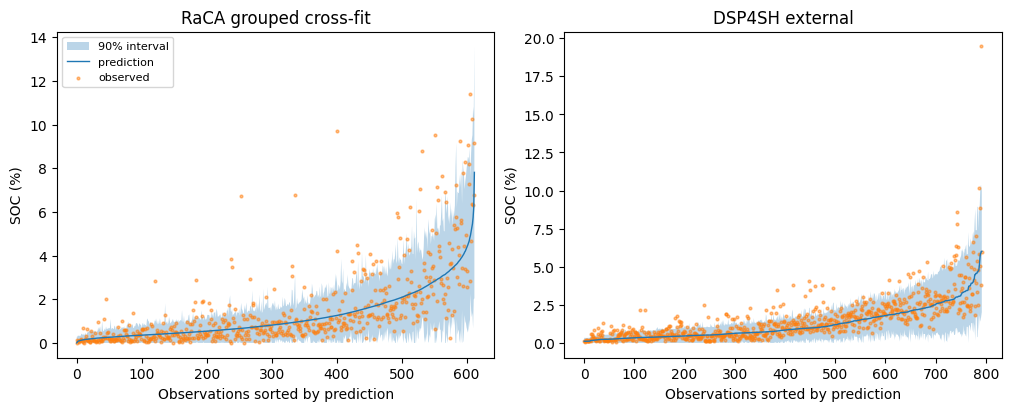

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, frame, title in [
    (axes[0], uncertainty['raca'], 'RaCA grouped cross-fit'),
    (axes[1], uncertainty['dsp4sh'], 'DSP4SH external'),
]:
    order = frame.predicted_SOC_pct.argsort()
    shown = frame.iloc[order].iloc[::max(1, len(frame) // 600)]
    ax.fill_between(range(len(shown)), shown.lower_90, shown.upper_90, alpha=0.3, label='90% interval')
    ax.plot(range(len(shown)), shown.predicted_SOC_pct, linewidth=1, label='prediction')
    ax.scatter(range(len(shown)), shown.observed_SOC_pct, s=4, alpha=0.5, label='observed')
    ax.set(title=title, xlabel='Observations sorted by prediction', ylabel='SOC (%)')
axes[0].legend(fontsize=8)
plt.show()

Map-ready artifacts are saved in `model_artifacts/soc_pct_uncertainty/`. Raster inference must first calculate the point-model prediction, append it as `point_prediction`, apply the saved uncertainty preprocessor/model, and multiply predicted absolute error by the saved calibration multiplier. The lower bound is clipped at zero.

## Bulk-density and SOC-density uncertainty

The same RaCA-only grouped cross-fitting and calibration procedure is applied independently to measured bulk density and directly modeled SOC density. Because bulk-density transfer to DSP4SH is poor, the operational bulk-density map interval uses a second, explicitly labeled DSP4SH scaling multiplier to obtain approximately 90% empirical DSP4SH coverage. This widens intervals only; it does not alter predictions, and DSP4SH is no longer independent validation for the mapped bulk-density intervals.

In [5]:
from modeling_pipeline import train_additional_target_uncertainty

bulk_density_uncertainty = train_additional_target_uncertainty('bulk_density', PROJECT_DIR)
bulk_density_uncertainty['point_metrics'], bulk_density_uncertainty['uncertainty_metrics']

(            dataset      n        R2      RMSE       MAE      Bias  \
 0  RaCA grouped OOF  79360  0.345671  0.206084  0.160996 -0.013353   
 1   DSP4SH external   1310 -0.220096  0.305790  0.239906 -0.094654   
 
    Mean_observed  Mean_predicted  
 0       1.280210        1.266857  
 1       1.347906        1.253252  ,
                   dataset      n  coverage_90  mean_interval_width  \
 0  RaCA grouped cross-fit  79360     0.900025             0.660441   
 1         DSP4SH external   1310     0.779389             0.680040   
 
    median_interval_width  mean_lower  mean_upper  
 0               0.648933    0.936637    1.597078  
 1               0.680804    0.913232    1.593271  )

In [6]:
soc_density_uncertainty = train_additional_target_uncertainty('soc_density', PROJECT_DIR)
soc_density_uncertainty['point_metrics'], soc_density_uncertainty['uncertainty_metrics']

(            dataset      n        R2      RMSE       MAE      Bias  \
 0  RaCA grouped OOF  16434  0.378175  0.015409  0.008196  0.000009   
 1   DSP4SH external   1345  0.547196  0.010202  0.006616 -0.000662   
 
    Mean_observed  Mean_predicted  
 0       0.018668        0.018677  
 1       0.018756        0.018094  ,
                   dataset      n  coverage_90  mean_interval_width  \
 0  RaCA grouped cross-fit  16434     0.900146              0.02971   
 1         DSP4SH external   1345     0.897398              0.02673   
 
    median_interval_width  mean_lower  mean_upper  
 0               0.024466    0.004282    0.033992  
 1               0.021523    0.005003    0.031733  )